In [107]:
from langgraph.graph import StateGraph, START, END, MessagesState

In [108]:
import sqlite3
db_path = "store.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [109]:
class AgentState(MessagesState):pass

In [110]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")
if not api_key:
    raise ValueError("GOOGLE_API_KEY not found in .env file!")
else:
    print("Key imported successfully!")

Key imported successfully!


In [111]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",   
    google_api_key=os.getenv("GOOGLE_API_KEY"),
)


In [112]:
def add(a:int, b:int)-> int:
    """ This function takes 2 agrs a and b , add two args and return"""
    return a+b

In [113]:
llm_with_tools = llm.bind_tools([add])

In [114]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, SystemMessage

In [115]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs")

In [116]:
def tool_calling_llm(state: AgentState): 
    return {"messages": [llm_with_tools.invoke( [sys_msg] + state["messages"]) ]}

In [117]:
graph = StateGraph(AgentState)

graph.add_node("tool_call", tool_calling_llm)
graph.add_node("tools", ToolNode([add]))


graph.add_edge(START, "tool_call")
graph.add_conditional_edges(
    "tool_call",
    tools_condition
)

graph.add_edge("tools",END)

In [118]:

app = graph.compile(checkpointer=memory)

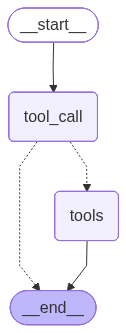

In [119]:
app

In [120]:
# for event in app.stream({"messages":[HumanMessage(content="give me latest ai news")]}):
#     for value in event.values():
#         print(value["messages"][-1].content)

In [121]:
config = {"configurable": {"thread_id": "11"}}

In [131]:
response = app.invoke({"messages": [HumanMessage(content="what is my name ")]}, config=config,stream_mode="values")


In [132]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

add two number 111 and 34343222 
================================== Ai Message ==================================
Tool Calls:
  add (dc142cb8-79c5-4bcb-b43a-d5b2f43fe738)
 Call ID: dc142cb8-79c5-4bcb-b43a-d5b2f43fe738
  Args:
    a: 111.0
    b: 34343222.0
================================= Tool Message =================================
Name: add

34343333
================================ Human Message =================================

hi my name is box
================================== Ai Message ==================================

Hello Box! It's nice to meet you. How can I help you today?
================================ Human Message =================================

add two number 111 and 34343222 
================================== Ai Message ==================================
Tool Calls:
  add (c0465493-9978-474c-8787-32440d6f5633)
 Call ID: c0465493-9978-474c-8787-32440d6f5633
  Args:
    a: 111